# Part 4 — Data Visualization & Machine Learning
### Student Performance Analysis & Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
df = pd.read_csv("students.csv")
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


## Task 1 — Data Exploration with Pandas

In [2]:
# Shape and data types
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

Shape: (15, 9)

Data types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [3]:
# Summary statistics
print(df.describe())

            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2.800000   1.000000  

In [4]:
# Pass / Fail counts
print("Pass/Fail counts:")
print(df['passed'].value_counts())

Pass/Fail counts:
passed
1    9
0    6
Name: count, dtype: int64


In [5]:
# Average score per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average scores — Passing students:")
print(df[df['passed'] == 1][subject_cols].mean().round(2))
print("\nAverage scores — Failing students:")
print(df[df['passed'] == 0][subject_cols].mean().round(2))

Average scores — Passing students:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average scores — Failing students:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [6]:
# Student with highest overall average across all 5 subjects
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_idx = df['temp_avg'].idxmax()
print(f"Top student: {df.loc[top_idx, 'name']} — Avg: {df.loc[top_idx, 'temp_avg']:.2f}")
df.drop(columns=['temp_avg'], inplace=True)

Top student: Diana — Avg: 94.00


## Task 2 — Data Visualization with Matplotlib

In [7]:
# Add avg_score column
df['avg_score'] = df[subject_cols].mean(axis=1)

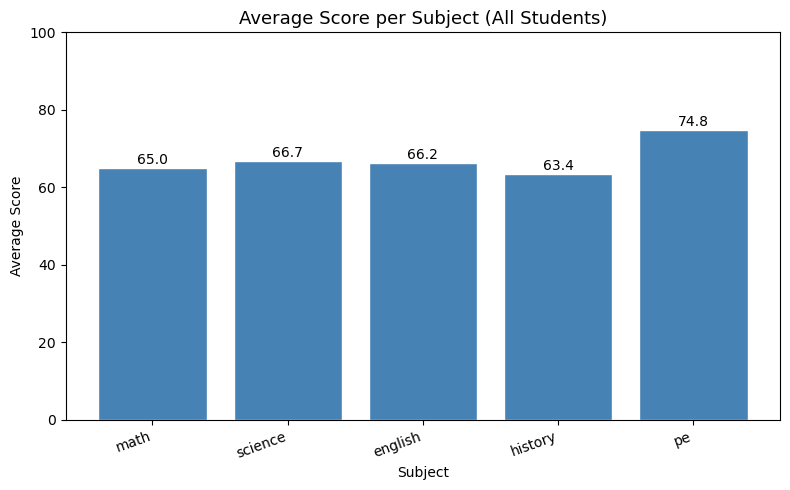

In [8]:
# Plot 1 — Bar Chart: average score per subject
fig, ax = plt.subplots(figsize=(8, 5))
avg_scores = df[subject_cols].mean()
ax.bar(avg_scores.index, avg_scores.values, color='steelblue', edgecolor='white')
ax.set_title("Average Score per Subject (All Students)", fontsize=13)
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_ylim(0, 100)
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(avg_scores.values):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("plot1_bar.png", dpi=120)
plt.show()

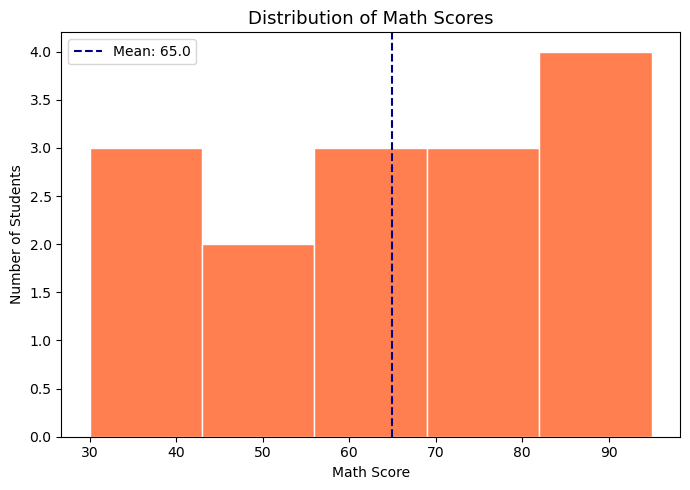

In [9]:
# Plot 2 — Histogram: math scores with mean line
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df['math'], bins=5, color='coral', edgecolor='white')
mean_math = df['math'].mean()
ax.axvline(mean_math, color='navy', linestyle='--', linewidth=1.5, label=f"Mean: {mean_math:.1f}")
ax.set_title("Distribution of Math Scores", fontsize=13)
ax.set_xlabel("Math Score")
ax.set_ylabel("Number of Students")
ax.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png", dpi=120)
plt.show()

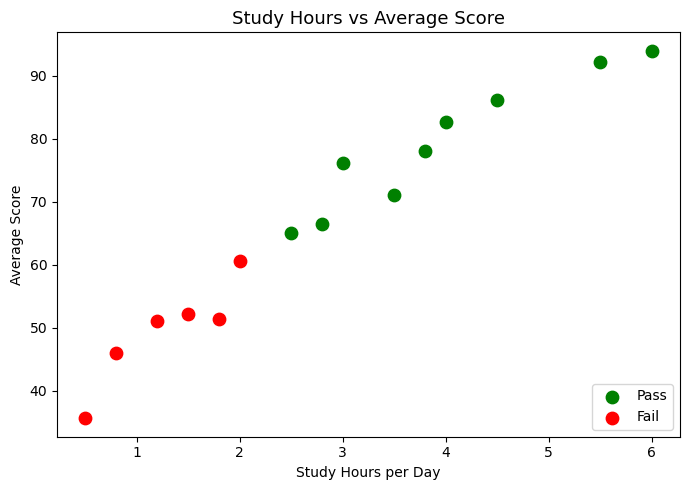

In [10]:
# Plot 3 — Scatter: study hours vs avg_score, coloured by passed
fig, ax = plt.subplots(figsize=(7, 5))
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
ax.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass', s=80, zorder=3)
ax.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red',   label='Fail', s=80, zorder=3)
ax.set_title("Study Hours vs Average Score", fontsize=13)
ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Average Score")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("plot3_scatter.png", dpi=120)
plt.show()

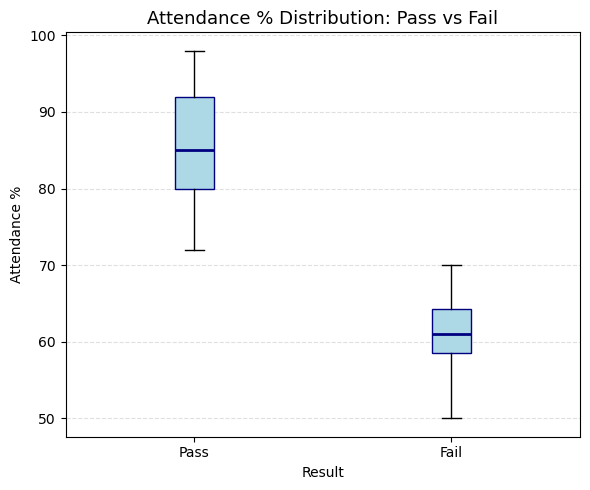

In [11]:
# Plot 4 — Box Plot: attendance_pct for Pass vs Fail
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([pass_att, fail_att], tick_labels=['Pass', 'Fail'], patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_title("Attendance % Distribution: Pass vs Fail", fontsize=13)
ax.set_xlabel("Result")
ax.set_ylabel("Attendance %")
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot4_boxplot.png", dpi=120)
plt.show()

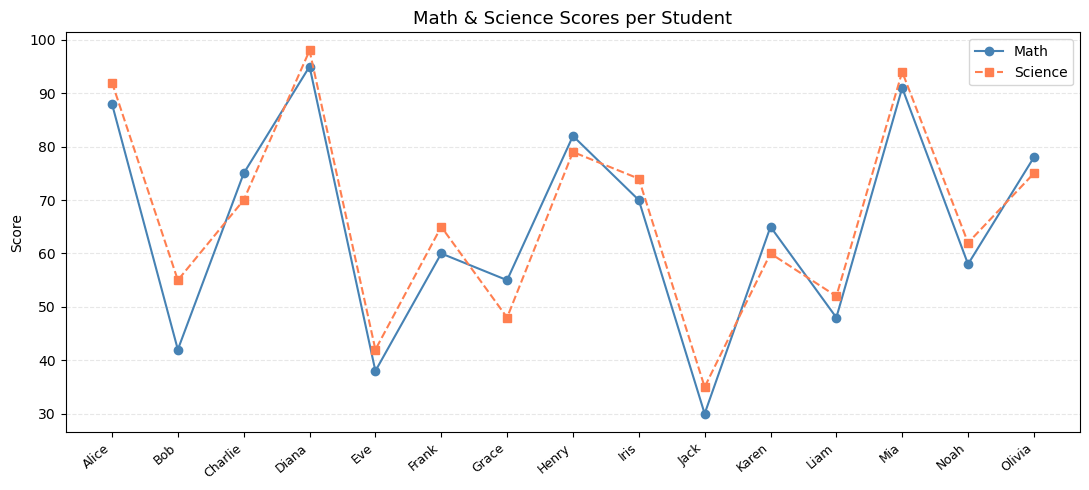

In [12]:
# Plot 5 — Line Plot: math & science per student
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df))
ax.plot(x, df['math'],    marker='o', linestyle='-',  label='Math',    color='steelblue')
ax.plot(x, df['science'], marker='s', linestyle='--', label='Science', color='coral')
ax.set_title("Math & Science Scores per Student", fontsize=13)
ax.set_ylabel("Score")
ax.set_xticks(list(x))
ax.set_xticklabels(df['name'].tolist(), rotation=40, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("plot5_line.png", dpi=120)
plt.show()

## Task 3 — Data Visualization with Seaborn

```
# Seaborn vs Matplotlib comparison (comment):
# Seaborn made the regression scatter plot much easier — sns.regplot() handles
# regression lines and confidence bands in a single call, while Matplotlib would
# require manual numpy polyfit. For bar charts, Matplotlib gave finer control over
# subplot layout and labels, whereas Seaborn's barplot needed less code for grouping.
```

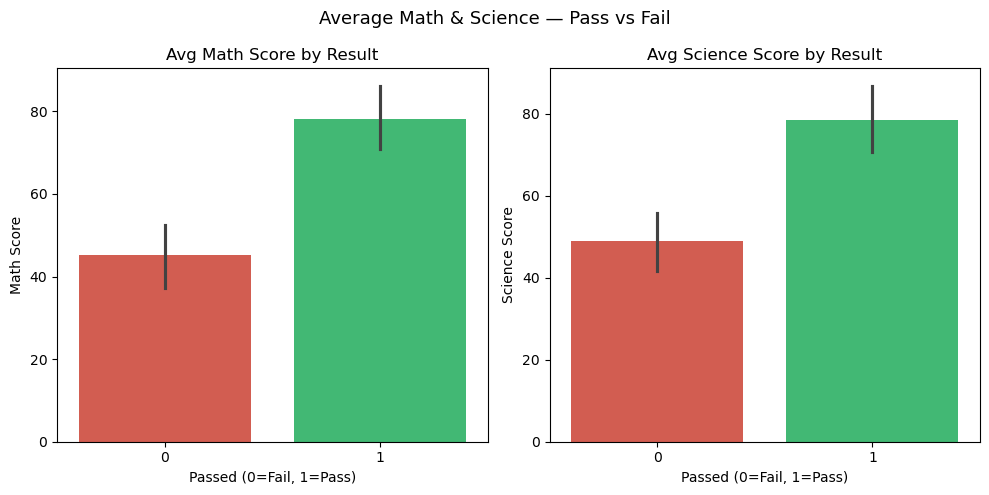

In [13]:
# Plot 6 — Seaborn bar: avg math & science by passed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=df, x='passed', y='math',    ax=ax1, hue='passed', palette={0:'#e74c3c',1:'#2ecc71'}, legend=False)
sns.barplot(data=df, x='passed', y='science', ax=ax2, hue='passed', palette={0:'#e74c3c',1:'#2ecc71'}, legend=False)
ax1.set_title("Avg Math Score by Result")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")
ax2.set_title("Avg Science Score by Result")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")
plt.suptitle("Average Math & Science — Pass vs Fail", fontsize=13)
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=120)
plt.show()

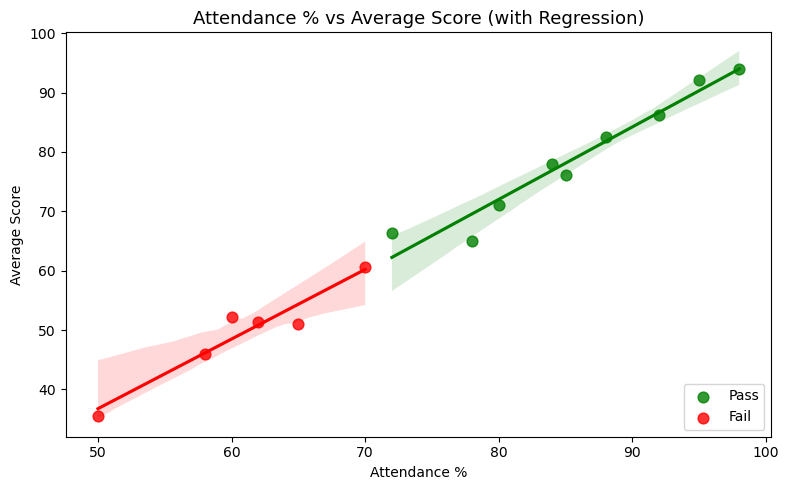

In [14]:
# Plot 7 — Seaborn scatter + regression: attendance vs avg_score
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            label='Pass', scatter_kws={'color':'green','s':60}, line_kws={'color':'green'}, ax=ax)
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            label='Fail', scatter_kws={'color':'red','s':60},   line_kws={'color':'red'},   ax=ax)
ax.set_title("Attendance % vs Average Score (with Regression)", fontsize=13)
ax.set_xlabel("Attendance %")
ax.set_ylabel("Average Score")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=120)
plt.show()

## Task 4 — Machine Learning with scikit-learn

In [15]:
# Step 1 — Prepare data
feature_cols = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 12 | Test size: 3


In [16]:
# Step 2 — Train Logistic Regression
model = LogisticRegression(random_state=42, max_iter=500)
model.fit(X_train_scaled, y_train)
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc * 100:.1f}%")

Training Accuracy: 100.0%


In [17]:
# Step 3 — Evaluate on test set
y_pred  = model.predict(X_test_scaled)
test_acc = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {test_acc * 100:.1f}%")

print("\nPer-student predictions:")
test_names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"  {name:<12} | Actual: {actual} | Predicted: {pred} | {result}")

Test Accuracy: 100.0%

Per-student predictions:
  Jack         | Actual: 0 | Predicted: 0 | ✅ Correct
  Liam         | Actual: 0 | Predicted: 0 | ✅ Correct
  Alice        | Actual: 1 | Predicted: 1 | ✅ Correct


Feature coefficients (sorted by |value|):
  english                      : +0.8125
  attendance_pct               : +0.5219
  study_hours_per_day          : +0.4844
  pe                           : +0.4750
  math                         : +0.4379
  science                      : +0.3230
  history                      : +0.2629


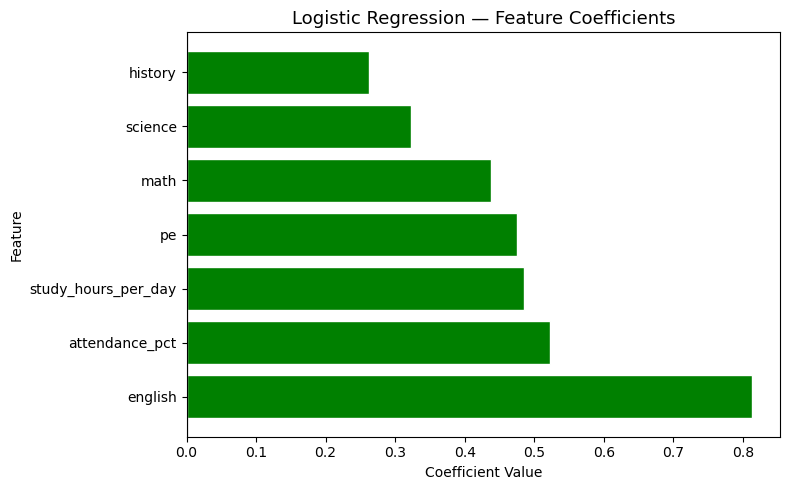

In [18]:
# Step 4 — Feature importance (model coefficients)
coefs = list(zip(feature_cols, model.coef_[0]))
coefs_sorted = sorted(coefs, key=lambda x: abs(x[1]), reverse=True)
print("Feature coefficients (sorted by |value|):")
for feat, coef in coefs_sorted:
    print(f"  {feat:<28} : {coef:+.4f}")

# Horizontal bar chart
features, values = zip(*coefs_sorted)
colors = ['green' if v > 0 else 'red' for v in values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features, values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Logistic Regression — Feature Coefficients", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png", dpi=120)
plt.show()

In [19]:
# Step 5 (Bonus) — Predict for a new student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]   # values match feature_cols order
new_scaled  = scaler.transform(new_student)
prediction  = model.predict(new_scaled)[0]
proba       = model.predict_proba(new_scaled)[0]

result_label = "Pass ✅" if prediction == 1 else "Fail ❌"
print(f"Prediction for new student: {result_label}")
print(f"Probability — Fail: {proba[0]:.2%}  |  Pass: {proba[1]:.2%}")

Prediction for new student: Pass ✅
Probability — Fail: 9.20%  |  Pass: 90.80%


c:\Users\krina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
